In [10]:
#LIME intro
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [2]:
#1. load the pre-trained ResNet model (ResNet18)
weights = models.ResNet18_Weights.DEFAULT #you can also try ResNet50: larger but slower
model = models.resnet18(weights=weights)
model.eval()
categories = weights.meta["categories"]

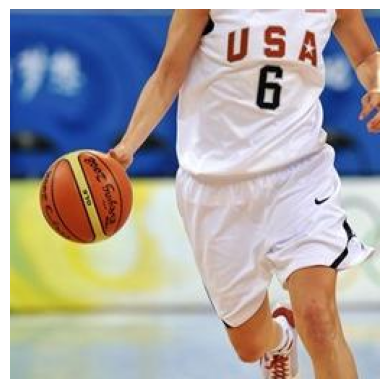

In [3]:
#2. load the image
img_path = '155.jpg'
img = Image.open(img_path).convert('RGB')

plt.figure()
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
#3. preprocess the image
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_img = preprocess(img).unsqueeze(0)

In [5]:
#4. make a prediction (true class: basketball)
with torch.no_grad():
    output = model(input_img)
    probabilities = F.softmax(output[0], dim=0)

top5_prob, top5_indices = torch.topk(probabilities, 5)
print("Top 5 Predictions:")
for i in range(5):
    label = categories[top5_indices[i]]
    confidence = top5_prob[i].item() * 100
    print(f"{i+1}. {label:<20} {confidence:.2f}%")

Top 5 Predictions:
1. basketball           99.94%
2. volleyball           0.05%
3. racket               0.00%
4. barbell              0.00%
5. soccer ball          0.00%


In [6]:
#5. get lime explanations
explainer = lime_image.LimeImageExplainer(random_state=42)

def predict_fn(images):
    batch = torch.stack([preprocess(Image.fromarray(im.astype(np.uint8))) for im in images])
    with torch.no_grad():
        probs = F.softmax(model(batch), dim=1)
    return probs.numpy()

img_array = np.array(img.resize((224, 224)))  # lime needs a numpy array

explanation = explainer.explain_instance(
    img_array,
    predict_fn,
    top_labels=5,
    num_samples=1000, # higher = more accurate but slower
    random_seed=42
)

100%|██████████| 1000/1000 [00:11<00:00, 85.09it/s]


Explaining class: basketball


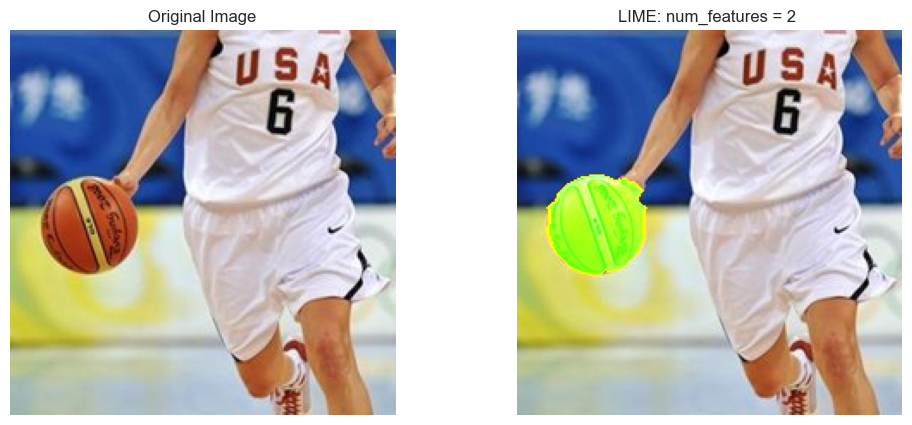

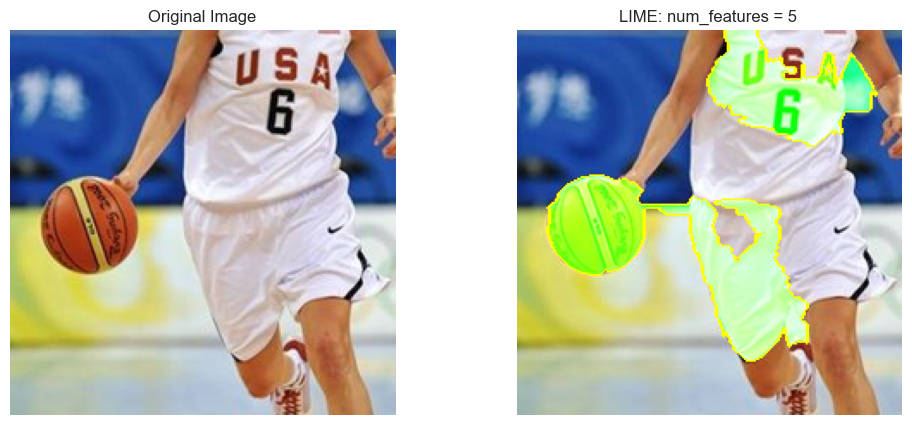

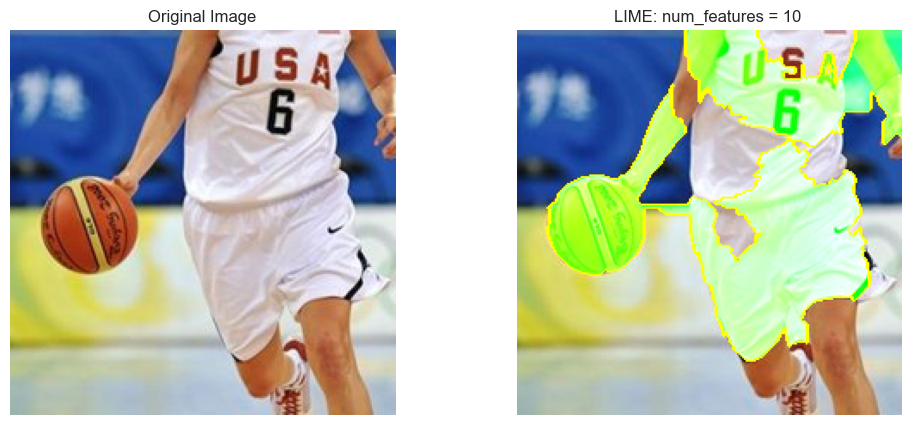

In [7]:
#6. visualize the explanation
top_class = explanation.top_labels[0]
print(f"Explaining class: {categories[top_class]}")

for nf in [2,5,10]: #for different numbers of highlighted superpixels (num_features)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    #left: original image
    axes[0].imshow(img_array)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    #right: LIME explanation
    explained_img, mask = explanation.get_image_and_mask(
        top_class,
        positive_only=False,
        num_features=nf,
        hide_rest=False
    )
    axes[1].imshow(mark_boundaries(explained_img / 255.0, mask))
    axes[1].set_title("LIME: num_features = %d " % nf)
    axes[1].axis("off")

#green = supports prediction, red = contradicts

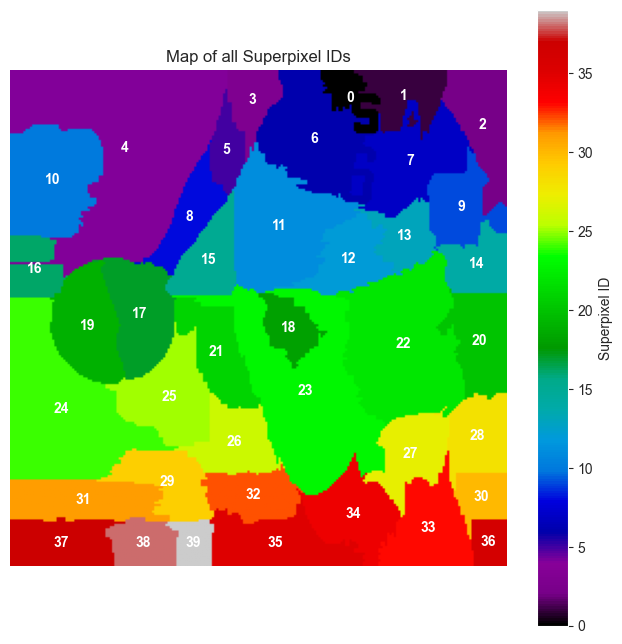

In [8]:
#7. extra stuff: map of all superpixels
segments = explanation.segments
plt.figure(figsize=(8, 8))
plt.imshow(segments, cmap='nipy_spectral')
plt.colorbar(label="Superpixel ID")
plt.title("Map of all Superpixel IDs")

for label in np.unique(segments):
    y, x = np.where(segments == label)
    plt.text(x.mean(), y.mean(), str(label),
             color='white', weight='bold', ha='center', va='center')

plt.axis('off')
plt.show()

In [9]:
#8. extra stuff: importance weights for all superpixels
dict_heatmap = explanation.local_exp[top_class]
print("Feature ID | Importance Weight")
print("----------------------------")
for feature_id, weight in dict_heatmap[:10]: #top 10 most important superpixels
    print(f"{feature_id:^10} | {weight:.4f}")

Feature ID | Importance Weight
----------------------------
    17     | 0.3370
    19     | 0.3360
    6      | 0.2729
    7      | 0.1590
    23     | 0.1574
    2      | 0.1491
    8      | 0.0989
    3      | 0.0981
    12     | 0.0973
    22     | 0.0969
